Checking hardware availibility

In [ ]:
# import torch

# print("GPU Available:", torch.cuda.is_available())
# print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
# print("GPU Being Used:", torch.cuda.current_device() if torch.cuda.is_available() else "No GPU")

: 

## Establishing the Architectural Baseline: 1-Dimensional Convolutional Neural Network (1D CNN)
A one-dimensional convolutional neural network (1D CNN) is a feedforward deep learning architecture
that applies learnable convolutional filters along a single spatial or temporal axis. Given an input
tensor $\mathbf{X} \in \mathbb{R}^{N \times C \times L}$, where $N$ is the batch size, $C$ is the
number of input channels, and $L$ is the sequence length, each convolutional layer computes a
feature map via the discrete cross-correlation:

$$y[i] = \sum_{k=0}^{K-1} w[k] \cdot x[i+k] + b$$

where $\mathbf{w} \in \mathbb{R}^{K}$ is the learnable kernel of size $K$, $b$ is a scalar bias,
and $i$ indexes the temporal dimension. Multiple filters extract parallel feature representations,
and successive layers capture hierarchical temporal abstractions of increasing receptive field.

### WHY 1D CNN for Time-Series Sensor Data?

Imagine your data as a **3D volume**:

- **X-axis:** Time frames (forward progression of the fall)
- **Y-axis:** Window size (50 frames = 1 second)
- **Z-axis:** Sensor features (Accel X, Accel Y, Gyro Z, etc.)

What the 1D CNN Does

The kernel moves **only along the time axis (X-axis)** while covering **all features (Z-axis)** at once.

- Kernel shape: `(features, kernel_size)` = `(10, 7)`
- Sweeps from `t=0` to `t=50` step by step

| Axis | Role | Kernel Movement |
|------|------|----------------|
| X (Time) | Sequential order | ✅ Slides along |
| Y (Window) | Fixed segment length | ❌ Does not move |
| Z (Features) | Multiple sensors | ✅ Fully covered |

## The Key Insight

> The kernel finds **temporal patterns** across **all sensors simultaneously** — like detecting "spike in Accel Y + drop in Gyro X" happening at the same moment in time.

No sensor mixing. No time destruction. Just pure temporal feature learning.

This cell implements the core MLOps preprocessing pipeline to transform raw CSV streams into PyTorch-ready 3D tensors while solving two major machine learning pitfalls:

**Phase 1: Leak-Proof Stratified Routing**

- **The Action:** Splits the dataset into Training (80%) and Validation (20%).
- **The Physics:** It strictly splits the dataset at the file level, rather than shuffling individual rows. This physically prevents temporal data leakage (where adjacent milliseconds of the same fall bleed into both train and test sets). Stratification ensures the exact ratio of Fall-to-Normal files is preserved.

**Phase 2: Dynamic Window Extraction**

- **The Action:** Sweeps across the CSVs, slicing the continuous sensor data into discrete 50-frame (1.0 second) chunks.
- **The Physics:** To solve the massive class imbalance (where 90% of data is just normal walking), it implements a Dynamic Stride. Normal walking windows step forward by 25 frames (standard 50% overlap). When a fall is detected, it triggers "burst mode," stepping forward by only 5 frames. This synthetically multiplies the minority fall data through heavy overlapping without needing to generate fake data.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm


# PHASE 1: The File Router (Stratified Split)

def get_stratified_file_splits(dataset_path, test_size=0.2):
    """
    Scans all CSVs, tags them as Positive (contains fall) or Negative,
    and splits the file paths to prevent data leakage.
    """
    base_dir = Path(dataset_path)
    all_csv_files = list(base_dir.rglob("*.csv"))
    
    print(f"Scanning {len(all_csv_files)} files for routing...")
    
    file_paths = []
    file_labels = []
    
    for file in tqdm(all_csv_files, desc="Tagging Files"):
        try:
            # Read only the FallCheck column to save memory
            df = pd.read_csv(file, usecols=['FallCheck'])
            # Tag: 1 if the file contains any falls, else 0
            contains_fall = 1 if df['FallCheck'].sum() > 0 else 0
            
            file_paths.append(str(file))
            file_labels.append(contains_fall)
        except Exception as e:
            print(f"Skipping unreadable file {file}: {e}")
            
    # Split the FILES, not the rows!
    train_files, val_files, train_labels, val_labels = train_test_split(
        file_paths, 
        file_labels, 
        test_size=test_size, 
        stratify=file_labels, # Ensures 80/20 ratio of falls is maintained
        random_state=42
    )
    
    print(f"\n--- Routing Successful ---")
    print(f"Train Files: {len(train_files)} (Files with Falls: {sum(train_labels)})")
    print(f"Val Files:   {len(val_files)} (Files with Falls: {sum(val_labels)})")
    
    return train_files, val_files


# PHASE 2: The Window Extractor

def extract_dynamic_windows(file_list, window_size=50, normal_stride=25, fall_stride=5, fall_threshold=0.4):
    """
    Iterates through a specific list of files, applies the sliding window,
    and dynamically changes the stride (overlap)
    """
    # The 9 sensor columns we actually care about
    features_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']
    
    X_list = []
    y_list = []
    
    for file in tqdm(file_list, desc="Extracting Windows"):
        df = pd.read_csv(file)
        
        # Safety check: If a file is shorter than our window size, skip it
        if len(df) < window_size:
            continue
            
        features = df[features_cols].values
        labels = df['FallCheck'].values
        total_rows = len(df)
        
        start = 0
        while start <= total_rows - window_size:
            # 1. Slice the window strictly chronologically
            window_X = features[start : start + window_size]
            window_y = labels[start : start + window_size]
            
            # 2. Determine if this specific window is a "Fall"
            is_fall = 1 if np.mean(window_y) >= fall_threshold else 0
            
            X_list.append(window_X)
            y_list.append(is_fall)
            
            # 3. Dynamic Stride (The Imbalance Trick)
            if is_fall == 1:
                start += fall_stride    # Heavy overlap (e.g., jump 5 steps) to multiply fall data
            else:
                start += normal_stride  # Normal overlap (e.g., jump 25 steps) for walking
                
    # Convert lists to massive 3D and 1D NumPy arrays
    X_array = np.array(X_list, dtype=np.float32)
    y_array = np.array(y_list, dtype=np.float32)
    
    return X_array, y_array



In [ ]:

# PHASE 3: Execution 


training_folder_path = Path("DataSet/Sample_Training")

train_files, val_files = get_stratified_file_splits(training_folder_path, test_size=0.2)

# 2. Extract Training Data
print("\n[Processing Training Set]")
X_train_raw, y_train = extract_dynamic_windows(
    train_files, 
    window_size=50, 
    normal_stride=25, 
    fall_stride=5
)

# 3. Extract Validation Data
print("\n[Processing Validation Set]")
X_val_raw, y_val = extract_dynamic_windows(
    val_files, 
    window_size=50, 
    normal_stride=25, 
    fall_stride=5
)

print("\n=== FINAL DATASET READY FOR SCALING ===")
print(f"X_train shape: {X_train_raw.shape} | y_train shape: {y_train.shape}")
print(f"Train Class Balance: 0: {np.sum(y_train==0)}, 1: {np.sum(y_train==1)}")
print(f"X_val shape:   {X_val_raw.shape} | y_val shape: {y_val.shape}")
print(f"Val Class Balance:   0: {np.sum(y_val==0)}, 1: {np.sum(y_val==1)}")

Scanning 2473 files for routing...


Tagging Files: 100%|██████████| 2473/2473 [00:54<00:00, 45.19it/s]



--- Routing Successful ---
Train Files: 1978 (Files with Falls: 1489)
Val Files:   495 (Files with Falls: 373)

[Processing Training Set]


Extracting Windows: 100%|██████████| 1978/1978 [00:20<00:00, 96.80it/s] 



[Processing Validation Set]


Extracting Windows: 100%|██████████| 495/495 [00:04<00:00, 101.45it/s]



=== FINAL DATASET READY FOR SCALING ===
X_train shape: (46781, 50, 9) | y_train shape: (46781,)
Train Class Balance: 0: 33364, 1: 13417
X_val shape:   (11592, 50, 9) | y_val shape: (11592,)
Val Class Balance:   0: 8207, 1: 3385


Model is defined

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 1. Safely Scale the 3D Data

print("Scaling data...")
num_train, time_steps, num_features = X_train_raw.shape
num_val = X_val_raw.shape[0]

# Flatten to 2D for the scaler
X_train_2d = X_train_raw.reshape(-1, num_features)
X_val_2d = X_val_raw.reshape(-1, num_features)

scaler = StandardScaler()
# CRITICAL: Fit ONLY on training data!
X_train_scaled = scaler.fit_transform(X_train_2d).reshape(num_train, time_steps, num_features)
X_val_scaled = scaler.transform(X_val_2d).reshape(num_val, time_steps, num_features)


# 2. PyTorch Dataset (The Channel Flip)

class FallDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        window = self.X[idx]
        label = self.y[idx]
        
        window_transposed = window.T
        
        return torch.tensor(window_transposed, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

train_dataset = FallDataset(X_train_scaled, y_train)
val_dataset = FallDataset(X_val_scaled, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# 3. The 1D-CNN Architecture

class FallDetector1DCNN(nn.Module):
    def __init__(self):
        super(FallDetector1DCNN, self).__init__()
        
        # Block 1: Input is 9 channels (sensors)
        self.conv1 = nn.Conv1d(in_channels=9, out_channels=64, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        # Block 2
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification Head
        self.fc1 = nn.Linear(in_features=128, out_features=64)
        self.dropout = nn.Dropout(0.5)
        # Raw logit output (No sigmoid here!)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.global_pool(F.relu(self.bn2(self.conv2(x))))
        
        x = torch.flatten(x, 1)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x.squeeze(1)

# Check for RTX 3050
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FallDetector1DCNN().to(device)

print(f"\nModel initialized and moved to: {device}")
print("Ready for Step 3: Training & F1 Evaluation!")

Scaling data...

Model initialized and moved to: cuda
Ready for Step 3: Training & F1 Evaluation!


Training

In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

# 1. Calculate pos_weight for BCEWithLogitsLoss
# We still have roughly a 2.5:1 imbalance, so 2.5x more attention to falls
num_zeros = np.sum(y_train == 0)
num_ones = np.sum(y_train == 1)
pos_weight_val = num_zeros / num_ones
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

# 2. Initialize Loss and Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30

print(f"Starting Training on {device}...")
print(f"Using pos_weight: {pos_weight_val:.2f}\n")

history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    # TRAINING PHASE

    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # The Holy Trinity
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    
    # VALIDATION PHASE (F1-Score Calculation)
    
    model.eval()
    val_loss = 0.0
    
    # Lists to store the predictions and true labels for the whole epoch
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            
            # Forward pass
            val_logits = model(val_X)
            v_loss = criterion(val_logits, val_y)
            val_loss += v_loss.item()
            
            # Convert logits to probabilities using Sigmoid
            val_probs = torch.sigmoid(val_logits)
            
            # Convert probabilities to absolute 0 or 1 using a 0.5 threshold
            val_preds = (val_probs > 0.5).float()
            
            # Move data back to CPU for sklearn metrics
            all_preds.extend(val_preds.cpu().numpy())
            all_targets.extend(val_y.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    
   
    # METRICS CALCULATION
   
    val_f1 = f1_score(all_targets, all_preds)
    val_precision = precision_score(all_targets, all_preds)
    val_recall = recall_score(all_targets, all_preds)
    val_acc = accuracy_score(all_targets, all_preds)
    
    
    # Print the epoch summary
    print(f"Epoch [{epoch+1:02d}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} "
          f"(Precision: {val_precision:.4f}, Recall: {val_recall:.4f})")
    #to plot the loss curves later
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

print("\n=== Training Complete ===")

Starting Training on cuda...
Using pos_weight: 2.49

Epoch [01/30] | Train Loss: 0.0616 | Val Loss: 0.1288 | Val F1: 0.9621 (Precision: 0.9608, Recall: 0.9634)
Epoch [02/30] | Train Loss: 0.0594 | Val Loss: 0.1225 | Val F1: 0.9645 (Precision: 0.9607, Recall: 0.9684)
Epoch [03/30] | Train Loss: 0.0596 | Val Loss: 0.1207 | Val F1: 0.9645 (Precision: 0.9621, Recall: 0.9669)
Epoch [04/30] | Train Loss: 0.0526 | Val Loss: 0.1266 | Val F1: 0.9659 (Precision: 0.9649, Recall: 0.9669)
Epoch [05/30] | Train Loss: 0.0545 | Val Loss: 0.1343 | Val F1: 0.9577 (Precision: 0.9453, Recall: 0.9705)
Epoch [06/30] | Train Loss: 0.0582 | Val Loss: 0.1299 | Val F1: 0.9627 (Precision: 0.9598, Recall: 0.9657)
Epoch [07/30] | Train Loss: 0.0557 | Val Loss: 0.1377 | Val F1: 0.9626 (Precision: 0.9560, Recall: 0.9693)
Epoch [08/30] | Train Loss: 0.0529 | Val Loss: 0.1415 | Val F1: 0.9599 (Precision: 0.9486, Recall: 0.9713)
Epoch [09/30] | Train Loss: 0.0533 | Val Loss: 0.1127 | Val F1: 0.9638 (Precision: 0.9561, 

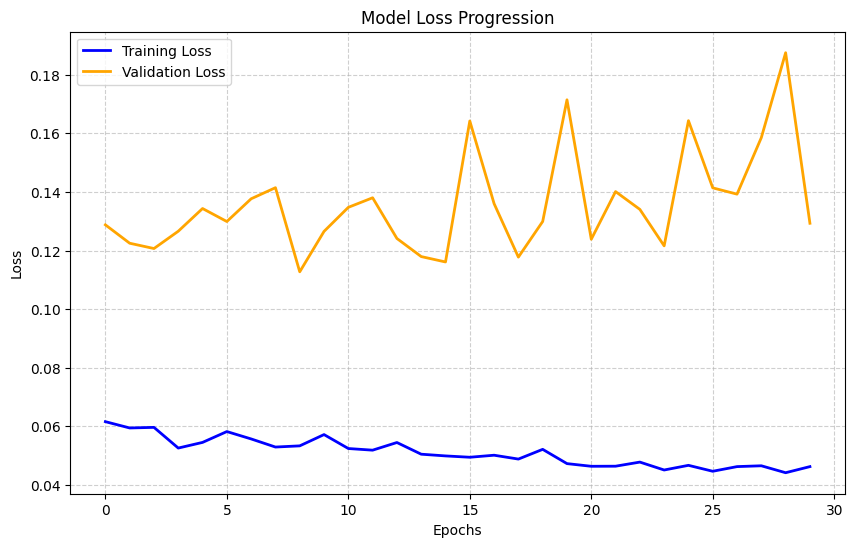

In [8]:
import matplotlib.pyplot as plt
# --- ADD THIS AT THE VERY END OF YOUR SCRIPT ---
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Validation Loss', color='orange', lw=2)

plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

the above graph is for model trianed on pos_weight == ratio of 0 and 1 

PLease refer to [model result](logs/EXP_0_1D_CNN.txt) for more experimentaion result


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
##### plot it ######
print("=== Starting Final Blind Test Evaluation ===\n")

# 1. Locate the test files
test_dir = Path("./DataSet/Sample_Test")
test_files = list(test_dir.rglob("*.csv"))
print(f"Found {len(test_files)} files in sample_test.")

# 2. Extract Windows (STRICTLY No Oversampling!)
print("Extracting test windows (maintaining real-world distribution)...")
X_test_raw, y_test = extract_dynamic_windows(
    test_files, 
    window_size=50, 
    normal_stride=25, 
    # No synthetic balancing on the test set!
    fall_stride=25  
)

# 3. Scale using the EXISTING fitted scaler (No data leakage!)
print("\nScaling test data...")
num_test, time_steps, num_features = X_test_raw.shape
X_test_2d = X_test_raw.reshape(-1, num_features)

# We use .transform(), NEVER .fit_transform() on test data
X_test_scaled_2d = scaler.transform(X_test_2d)
X_test_scaled = X_test_scaled_2d.reshape(num_test, time_steps, num_features)

# 4. Wrap in PyTorch DataLoader
test_dataset = FallDataset(X_test_scaled, y_test)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 5. Run Inference on the GPU
print(f"Running inference on {device}...")
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        logits = model(batch_X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(batch_y.numpy())

# 6. Generate Final Metrics
print("\nFor Train Fall Stride=5 & Val Fall Stride=25")

print("\n==================================================")
print("             FINAL HOLD-OUT TEST RESULTS          ")
print("==================================================")
print(classification_report(test_targets, test_preds, target_names=['Normal (0)', 'Fall (1)']))

# Optional: Print the raw Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly ignored normal walking): {cm[0][0]}")
print(f"False Positives (False alarms): {cm[0][1]}")
print(f"False Negatives (Missed actual falls): {cm[1][0]}")
print(f"True Positives (Successfully caught falls): {cm[1][1]}")

=== Starting Final Blind Test Evaluation ===

Found 586 files in sample_test.
Extracting test windows (maintaining real-world distribution)...


Extracting Windows: 100%|██████████| 586/586 [00:05<00:00, 114.44it/s]



Scaling test data...
Running inference on cuda...

For Train Fall Stride=5 & Val Fall Stride=25

             FINAL HOLD-OUT TEST RESULTS          
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.99      9674
    Fall (1)       0.83      0.93      0.87       967

    accuracy                           0.98     10641
   macro avg       0.91      0.95      0.93     10641
weighted avg       0.98      0.98      0.98     10641


Confusion Matrix:
True Negatives (Correctly ignored normal walking): 9489
False Positives (False alarms): 185
False Negatives (Missed actual falls): 72
True Positives (Successfully caught falls): 895


###  Experiment 3

Configuration
POS_WEIGHT==1

![Loss Curve](./images/1dcnn_pos_1.png)

###  Final Hold-Out Test Results

| Class        | Precision | Recall | F1-Score | Support |
|--------------|----------|--------|----------|---------|
| Normal (0)   | 0.99     | 0.98   | 0.99     | 9674    |
| Fall (1)     | 0.84     | 0.92   | 0.88     | 967     |

---

###  Overall Metrics

- **Accuracy:** 0.98  
- **Macro Avg:** Precision 0.92 | Recall 0.95 | F1 0.93  
- **Weighted Avg:** Precision 0.98 | Recall 0.98 | F1 0.98  

---

###  Confusion Matrix Breakdown

- **True Negatives:** 9511 *(Correctly ignored normal walking)*  
- **False Positives:** 163 *(False alarms)*  
- **False Negatives:** 81 *(Missed actual falls)*  
- **True Positives:** 886 *(Successfully caught falls)*

injecting with noise to check the robustness of the model


=== Starting Noise Stress Test Curve Generation ===
Testing   0% noise...
Testing   5% noise...
Testing  10% noise...
Testing  15% noise...
Testing  20% noise...
Testing  30% noise...
Testing  40% noise...
Testing  50% noise...
Testing  75% noise...
Testing 100% noise...


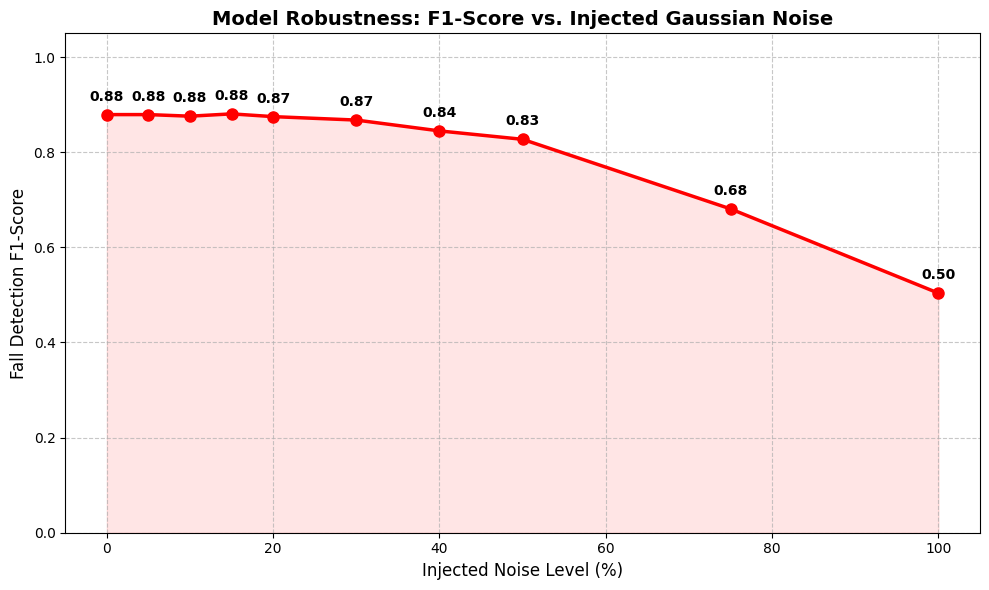


Stress Test Complete! Look at the graph to find the model's breaking point.


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader

# 1. Define the noise levels you want to test (0.0 = 0%, 1.0 = 100% static)
noise_levels = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]
f1_scores = []

print("=== Starting Noise Stress Test Curve Generation ===")
model.eval() # Ensure model is locked in evaluation mode

for noise_level in noise_levels:
    print(f"Testing {noise_level*100: >3.0f}% noise...")
    
    # Generate and inject noise
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X_test_scaled.shape)
    X_test_noisy = X_test_scaled + noise
    
    # Wrap in DataLoader
    noisy_test_dataset = FallDataset(X_test_noisy, y_test)
    noisy_test_loader = DataLoader(noisy_test_dataset, batch_size=128, shuffle=False)
    
    # Run Inference
    noisy_preds = []
    with torch.no_grad():
        for batch_X, _ in noisy_test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            noisy_preds.extend(preds.cpu().numpy())
            
    # Calculate F1-Score (Target = 1 for Falls)
    current_f1 = f1_score(test_targets, noisy_preds)
    f1_scores.append(current_f1)


# 2. Plotting the Degradation Curve

plt.figure(figsize=(10, 6))

# Plot the line
noise_percentages = [n * 100 for n in noise_levels]
plt.plot(noise_percentages, f1_scores, marker='o', linestyle='-', color='red', linewidth=2.5, markersize=8)

# Formatting the graph to look professional
plt.title("Model Robustness: F1-Score vs. Injected Gaussian Noise", fontsize=14, fontweight='bold')
plt.xlabel("Injected Noise Level (%)", fontsize=12)
plt.ylabel("Fall Detection F1-Score", fontsize=12)

plt.ylim(0.0, 1.05) 
plt.grid(True, linestyle='--', alpha=0.7)

# Add exact F1-score numbers floating above each dot
for i, txt in enumerate(f1_scores):
    plt.annotate(f"{txt:.2f}", 
                 (noise_percentages[i], f1_scores[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=10,
                 fontweight='bold')

# Fill the area under the curve lightly for style
plt.fill_between(noise_percentages, f1_scores, color='red', alpha=0.1)

plt.tight_layout()
plt.show()

print("\nStress Test Complete! Look at the graph to find the model's breaking point.")

Visualization to check robustness

Total False Positives found: 183
Total False Negatives found: 65

--- Plotting top 3 False Positives (False Alarms) ---


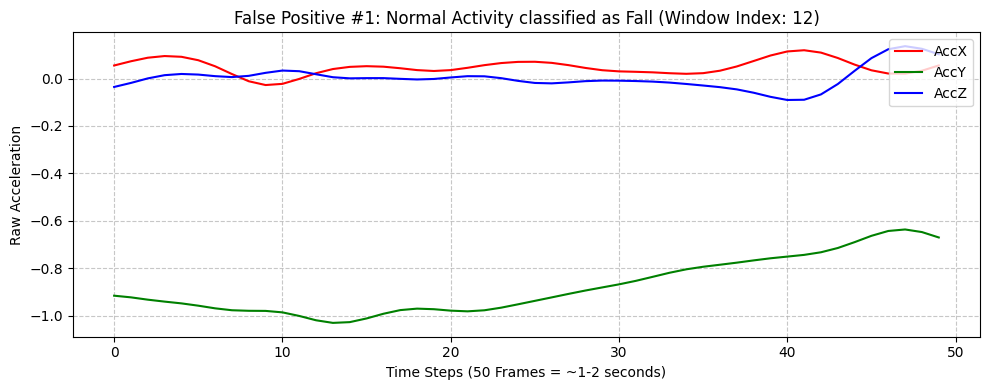

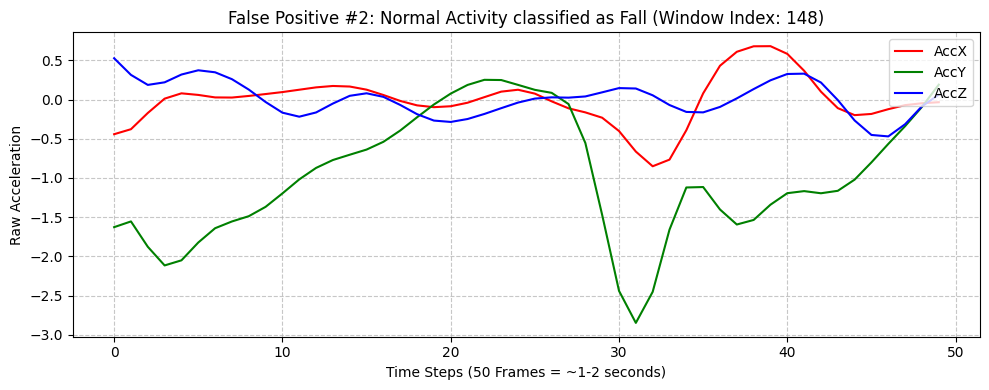

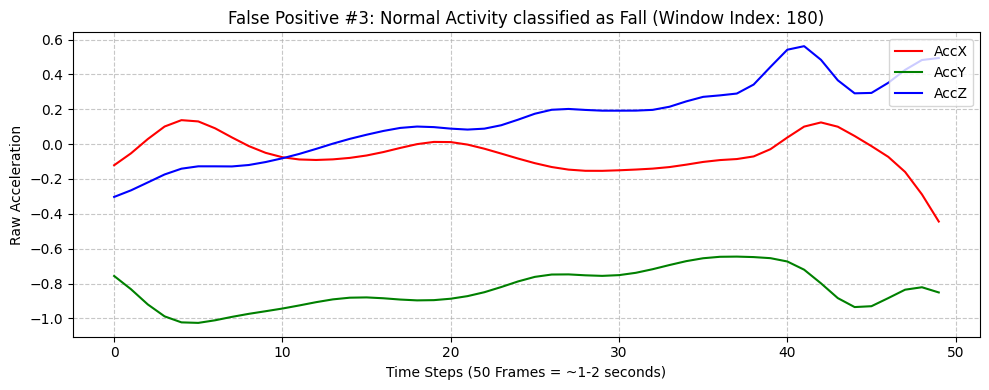


--- Plotting top 2 False Negatives (Missed Falls) ---


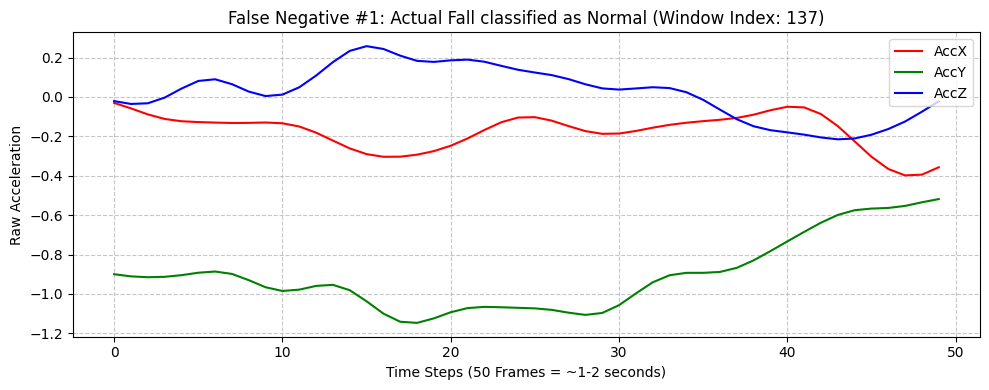

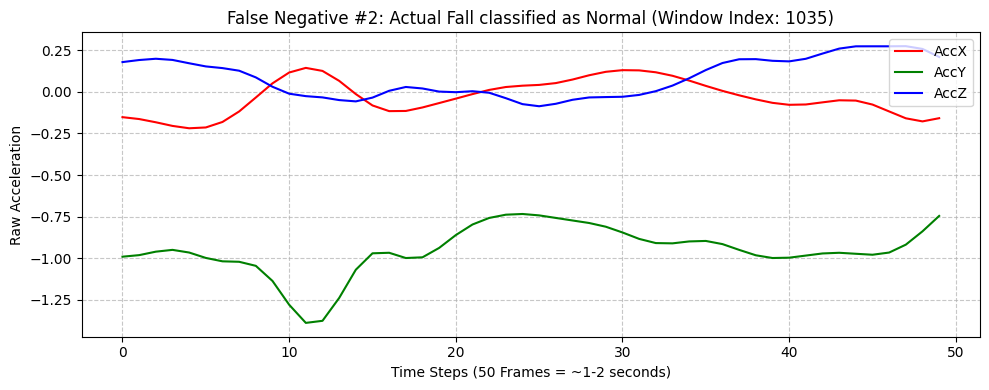

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert lists back to NumPy arrays for easy searching
true_labels = np.array(test_targets)
predictions = np.array(test_preds) 

# False Positive: True label is 0 (Normal), but Model predicted 1 (Fall)
fp_indices = np.where((true_labels == 0) & (predictions == 1))[0]

# False Negative: True label is 1 (Fall), but Model predicted 0 (Normal)
fn_indices = np.where((true_labels == 1) & (predictions == 0))[0]

print(f"Total False Positives found: {len(fp_indices)}")
print(f"Total False Negatives found: {len(fn_indices)}")

# 3. The Plotting Engine
def plot_sensor_window(index, title):
    
    window = X_test_raw[index]
    
    # Extract the first 3 columns: AccX, AccY, AccZ
    acc_x = window[:, 0]
    acc_y = window[:, 1]
    acc_z = window[:, 2]
    
    plt.figure(figsize=(10, 4))
    plt.plot(acc_x, label='AccX', color='red', linewidth=1.5)
    plt.plot(acc_y, label='AccY', color='green', linewidth=1.5)
    plt.plot(acc_z, label='AccZ', color='blue', linewidth=1.5)
    
    plt.title(f"{title} (Window Index: {index})")
    plt.xlabel("Time Steps (50 Frames = ~1-2 seconds)")
    plt.ylabel("Raw Acceleration")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 4. Generate the Graphs

print("\n--- Plotting top 3 False Positives (False Alarms) ---")
for i in range(min(3, len(fp_indices))):
    plot_sensor_window(fp_indices[i], f"False Positive #{i+1}: Normal Activity classified as Fall")

print("\n--- Plotting top 2 False Negatives (Missed Falls) ---")
for i in range(min(2, len(fn_indices))):
    plot_sensor_window(fn_indices[i], f"False Negative #{i+1}: Actual Fall classified as Normal")

In [ ]:
# import torch

# # Define a safe file name (usually .pth or .pt extension is used for PyTorch)
# checkpoint_path = "fall_detector_1dcnn_9_channels_v1.pth"

# # Save only the weights (state_dict)
# torch.save(model.state_dict(), checkpoint_path)

# print(f"Success! Model weights safely backed up to: {checkpoint_path}")

Success! Model weights safely backed up to: fall_detector_1dcnn_9_channels_v1.pth


The next method is not right yet it's needed to done

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

print("=== Starting Experiment: Naive Extraction (Frankenstein Windows) ===")

def extract_naive_windows(file_list, window_size=50, stride=25, fall_threshold=0.4):
    """
    The "wrong" way to do it: Smashes all files into one giant dataframe first.
    """
    print("Concatenating all files into one massive block...")
    # 1. Read all CSVs and smash them together, ignoring boundaries
    df_list = [pd.read_csv(f) for f in file_list]
    giant_df = pd.concat(df_list, ignore_index=True)
    
    features_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']
    features = giant_df[features_cols].values
    labels = giant_df['FallCheck'].values
    
    X_list = []
    y_list = []
    
    total_rows = len(giant_df)
    start = 0
    
    print("Extracting windows across boundaries...")
    while start <= total_rows - window_size:
        window_X = features[start : start + window_size]
        window_y = labels[start : start + window_size]
        
        is_fall = 1 if np.mean(window_y) >= fall_threshold else 0
        
        X_list.append(window_X)
        y_list.append(is_fall)
        
        start += stride # We use a constant stride of 25 for testing
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# Run the Experiment

# Extract the naive windows
X_test_naive, y_test_naive = extract_naive_windows(test_files, window_size=50, stride=25)

#  Scale them using your EXISTING scaler
num_test_naive, time_steps, num_features = X_test_naive.shape
X_test_naive_2d = X_test_naive.reshape(-1, num_features)
X_test_scaled_naive = scaler.transform(X_test_naive_2d).reshape(num_test_naive, time_steps, num_features)


naive_dataset = FallDataset(X_test_scaled_naive, y_test_naive)
naive_loader = DataLoader(naive_dataset, batch_size=128, shuffle=False)

# Run Inference
model.eval()
naive_preds = []

with torch.no_grad():
    for batch_X, _ in naive_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        preds = (torch.sigmoid(logits) > 0.5).float()
        naive_preds.extend(preds.cpu().numpy())

#  Show Results
print("\n==================================================")
print("     NAIVE HOLD-OUT TEST RESULTS (NO BOUNDARIES)  ")
print("==================================================")
print(classification_report(y_test_naive, naive_preds, target_names=['Normal (0)', 'Fall (1)']))

cm_naive = confusion_matrix(y_test_naive, naive_preds)
print("\nNaive Confusion Matrix:")
print(f"True Negatives: {cm_naive[0][0]}")
print(f"False Positives: {cm_naive[0][1]}")
print(f"False Negatives: {cm_naive[1][0]}")
print(f"True Positives: {cm_naive[1][1]}")

=== Starting Experiment: Naive Extraction (Frankenstein Windows) ===
Concatenating all files into one massive block...
Extracting windows across boundaries...

     NAIVE HOLD-OUT TEST RESULTS (NO BOUNDARIES)  
              precision    recall  f1-score   support

  Normal (0)       0.98      0.98      0.98     10012
    Fall (1)       0.86      0.88      0.87      1499

    accuracy                           0.97     11511
   macro avg       0.92      0.93      0.92     11511
weighted avg       0.97      0.97      0.97     11511


Naive Confusion Matrix:
True Negatives: 9793
False Positives: 219
False Negatives: 181
True Positives: 1318


This method leaves the extra not covered tuples in each csv file while creating windows

In [ ]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

print("=== Starting Strict Buffer Testing (Dropping Incomplete Tails) ===")

def extract_strict_test_windows(dataset_path, window_size=50, stride=25, fall_threshold=0.4):
    """
    Processes files individually. 
    Extracts strict 50-step windows with consistent overlap.
    Ignores any leftover frames at the end of the file.
    """
    base_dir = Path(dataset_path)
    # This automatically digs into all the SAXX folders and grabs the CSVs
    test_files = list(base_dir.rglob("*.csv")) 
    print(f"Found {len(test_files)} files in {dataset_path}.")
    
    features_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']
    
    X_list = []
    y_list = []
    
    for file in test_files:
        df = pd.read_csv(file)
        total_rows = len(df)
        
        # If the file is smaller than 50 frames, we can't make a window. Skip it.
        if total_rows < window_size:
            continue
            
        features = df[features_cols].values
        labels = df['FallCheck'].values
        
        start = 0
        # RULE: If start + 50 exceeds the total rows (e.g., last 10 frames of 910), 
        # the loop breaks and drops them perfectly.
        while start + window_size <= total_rows:
            window_X = features[start : start + window_size]
            window_y = labels[start : start + window_size]
            
            is_fall = 1 if np.mean(window_y) >= fall_threshold else 0
            
            X_list.append(window_X)
            y_list.append(is_fall)
            
            # Consistent stride for every single window (no dynamic oversampling here!)
            start += stride
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Run the Final Strict Test

X_test_strict, y_test_strict = extract_strict_test_windows("./DataSet/Sample_Test", window_size=50, stride=25)

#  Scaleing using your EXISTING fitted scaler (No data leakage!)
num_test_strict, time_steps, num_features = X_test_strict.shape
X_test_strict_2d = X_test_strict.reshape(-1, num_features)
X_test_scaled_strict = scaler.transform(X_test_strict_2d).reshape(num_test_strict, time_steps, num_features)

# Load into PyTorch
strict_dataset = FallDataset(X_test_scaled_strict, y_test_strict)
strict_loader = DataLoader(strict_dataset, batch_size=128, shuffle=False)

# 4. Run Inference with our trained 9-channel model
model.eval()
strict_preds = []

with torch.no_grad():
    for batch_X, _ in strict_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        preds = (torch.sigmoid(logits) > 0.5).float()
        strict_preds.extend(preds.cpu().numpy())

# 5. Show Results
print("\n==================================================")
print("     STRICT BUFFER HOLD-OUT TEST RESULTS          ")
print("==================================================")
print(classification_report(y_test_strict, strict_preds, target_names=['Normal (0)', 'Fall (1)']))

cm_strict = confusion_matrix(y_test_strict, strict_preds)
print("\nStrict Confusion Matrix:")
print(f"True Negatives: {cm_strict[0][0]}")
print(f"False Positives: {cm_strict[0][1]}")
print(f"False Negatives: {cm_strict[1][0]}")
print(f"True Positives: {cm_strict[1][1]}")

=== Starting Strict Buffer Testing (Dropping Incomplete Tails) ===
Found 586 files in ./DataSet/Sample_Test.

     STRICT BUFFER HOLD-OUT TEST RESULTS          
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.99      9674
    Fall (1)       0.83      0.93      0.88       967

    accuracy                           0.98     10641
   macro avg       0.91      0.96      0.93     10641
weighted avg       0.98      0.98      0.98     10641


Strict Confusion Matrix:
True Negatives: 9491
False Positives: 183
False Negatives: 65
True Positives: 902


## Feature Engineering: Signal Vector Magnitude (SVM)

### Motivation
Raw accelerometer axes (X, Y, Z) are orientation-dependent. Wrist rotation during a fall
distributes the impact spike unpredictably across axes, causing false negatives. SVM solves
this via the **Euclidean norm**, producing a rotationally invariant impact channel:

$$\text{SVM} = \sqrt{A_x^2 + A_y^2 + A_z^2}$$

### Tensor Transformation Pipeline

| Step | Operation | Tensor Shape |
|------|-----------|-------------|
| A — Raw input | 9 physical sensor channels | `[B, 50, 9]` |
| B — SVM extraction | `np.sqrt(np.sum(accel²,axis=-1))` | `[B, 50, 1]` |
| C — Concatenation | Append SVM as 10th channel | `[B, 50, 10]` |
| D — PyTorch permute | Transpose for `nn.Conv1d` | `[B, 10, 50]` |

### Architectural Impact

- **Saved network capacity** — the model receives the Euclidean norm pre-computed rather
  than learning Pythagoras implicitly from raw axes across 50 frames.
- **Anchored attention** — the SVM spike acts as a high-magnitude anchor in the sequence,
  allowing the Multi-Head Attention mechanism to localize the exact moment of impact and
  contrast it against the pre-fall motion context.

In [13]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("=== BUILDING VERSION 2.0 (10-Channel SMV Pipeline) ===")

# ==========================================
# 1. The V2 Window Extractor (Now with SMV!)
# ==========================================
def extract_windows_v2_smv(file_list, window_size=50, normal_stride=25, fall_stride=5, fall_threshold=0.4):
    X_list, y_list = [], []
    
    for file in tqdm(file_list, desc="Extracting V2 Windows & Injecting SMV"):
        df = pd.read_csv(file)
        
        if len(df) < window_size:
            continue
            
        # THE MAGIC TRICK: Calculate SMV in RAM
        df['SMV'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)
        
        # We now have 10 features!
        features_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ', 'SMV']
        features = df[features_cols].values
        labels = df['FallCheck'].values
        total_rows = len(df)
        
        start = 0
        while start <= total_rows - window_size:
            window_X = features[start : start + window_size]
            window_y = labels[start : start + window_size]
            
            is_fall = 1 if np.mean(window_y) >= fall_threshold else 0
            
            X_list.append(window_X)
            y_list.append(is_fall)
            
            # Dynamic stride to handle class imbalance exactly like V1
            start += fall_stride if is_fall == 1 else normal_stride
                
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ==========================================
# 2. Extract and Scale
# ==========================================
print("\n[Processing Training Set V2]")
X_train_v2, y_train_v2 = extract_windows_v2_smv(train_files)

print("\n[Processing Validation Set V2]")
X_val_v2, y_val_v2 = extract_windows_v2_smv(val_files)

print(f"\nNew Shapes -> Train: {X_train_v2.shape} | Val: {X_val_v2.shape}")

# Fit a BRAND NEW scaler because we have 10 columns now
scaler_v2 = StandardScaler()
num_train, time_steps, num_features = X_train_v2.shape
num_val = X_val_v2.shape[0]

X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2.reshape(-1, num_features)).reshape(num_train, time_steps, num_features)
X_val_scaled_v2 = scaler_v2.transform(X_val_v2.reshape(-1, num_features)).reshape(num_val, time_steps, num_features)

# ==========================================
# 3. DataLoader & V2 Architecture Setup
# ==========================================
class FallDatasetV2(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        # Transpose from (50, 10) to (10, 50) for PyTorch 1D-CNN
        return torch.tensor(self.X[idx].T, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

train_loader_v2 = DataLoader(FallDatasetV2(X_train_scaled_v2, y_train_v2), batch_size=128, shuffle=True)
val_loader_v2 = DataLoader(FallDatasetV2(X_val_scaled_v2, y_val_v2), batch_size=128, shuffle=False)

# UPGRADED MODEL ARCHITECTURE
class FallDetector1DCNN_V2(nn.Module):
    def __init__(self):
        super(FallDetector1DCNN_V2, self).__init__()
        # UPDATE: in_channels is now 10!
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=64, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.fc1 = nn.Linear(in_features=128, out_features=64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.global_pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x.squeeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = FallDetector1DCNN_V2().to(device)

print(f"\nVersion 2.0 Model initialized on: {device}")
print("Ready for Training Loop!")

=== BUILDING VERSION 2.0 (10-Channel SMV Pipeline) ===

[Processing Training Set V2]


Extracting V2 Windows & Injecting SMV: 100%|██████████| 1978/1978 [00:08<00:00, 237.03it/s]



[Processing Validation Set V2]


Extracting V2 Windows & Injecting SMV: 100%|██████████| 495/495 [00:01<00:00, 254.54it/s]



New Shapes -> Train: (46650, 50, 10) | Val: (11723, 50, 10)

Version 2.0 Model initialized on: cuda
Ready for Training Loop!


In [14]:
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

# 1. Calculate pos_weight for V2 data
num_zeros_v2 = np.sum(y_train_v2 == 0)
num_ones_v2 = np.sum(y_train_v2 == 1)
pos_weight_val_v2 = num_zeros_v2 / num_ones_v2
pos_weight_tensor_v2 = torch.tensor([pos_weight_val_v2], dtype=torch.float32).to(device)

# 2. Initialize Loss and Optimizer for model_v2
criterion_v2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor_v2)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001)

epochs = 30

print(f"Starting V2 Training on {device}...")
print(f"Using pos_weight: {pos_weight_val_v2:.2f}\n")

for epoch in range(epochs):
    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_v2.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader_v2:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer_v2.zero_grad()
        predictions = model_v2(batch_X)
        loss = criterion_v2(predictions, batch_y)
        loss.backward()
        optimizer_v2.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader_v2)
    
    # ==========================================
    # VALIDATION PHASE (F1-Score Calculation)
    # ==========================================
    model_v2.eval()
    val_loss = 0.0
    
    all_preds_v2 = []
    all_targets_v2 = []
    
    with torch.no_grad():
        for val_X, val_y in val_loader_v2:
            val_X, val_y = val_X.to(device), val_y.to(device)
            
            val_logits = model_v2(val_X)
            v_loss = criterion_v2(val_logits, val_y)
            val_loss += v_loss.item()
            
            val_probs = torch.sigmoid(val_logits)
            val_preds = (val_probs > 0.5).float()
            
            all_preds_v2.extend(val_preds.cpu().numpy())
            all_targets_v2.extend(val_y.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader_v2)
    
    # ==========================================
    # METRICS CALCULATION
    # ==========================================
    val_f1 = f1_score(all_targets_v2, all_preds_v2)
    val_precision = precision_score(all_targets_v2, all_preds_v2)
    val_recall = recall_score(all_targets_v2, all_preds_v2)
    
    print(f"Epoch [{epoch+1:02d}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} "
          f"(Precision: {val_precision:.4f}, Recall: {val_recall:.4f})")

print("\n=== Version 2.0 Training Complete ===")

Starting V2 Training on cuda...
Using pos_weight: 2.47

Epoch [01/30] | Train Loss: 0.2087 | Val Loss: 0.1486 | Val F1: 0.9434 (Precision: 0.9447, Recall: 0.9422)
Epoch [02/30] | Train Loss: 0.1352 | Val Loss: 0.1242 | Val F1: 0.9430 (Precision: 0.9180, Recall: 0.9695)
Epoch [03/30] | Train Loss: 0.1189 | Val Loss: 0.1287 | Val F1: 0.9358 (Precision: 0.8994, Recall: 0.9754)
Epoch [04/30] | Train Loss: 0.1125 | Val Loss: 0.1314 | Val F1: 0.9476 (Precision: 0.9361, Recall: 0.9594)
Epoch [05/30] | Train Loss: 0.1031 | Val Loss: 0.1222 | Val F1: 0.9432 (Precision: 0.9192, Recall: 0.9686)
Epoch [06/30] | Train Loss: 0.0965 | Val Loss: 0.1203 | Val F1: 0.9493 (Precision: 0.9312, Recall: 0.9680)
Epoch [07/30] | Train Loss: 0.0945 | Val Loss: 0.1140 | Val F1: 0.9440 (Precision: 0.9156, Recall: 0.9742)
Epoch [08/30] | Train Loss: 0.0905 | Val Loss: 0.1149 | Val F1: 0.9435 (Precision: 0.9120, Recall: 0.9772)
Epoch [09/30] | Train Loss: 0.0915 | Val Loss: 0.1337 | Val F1: 0.9547 (Precision: 0.956

In [16]:
import os
from pathlib import Path

print("=== Starting V2 Strict Buffer Testing (10-Channel) ===")

def extract_strict_test_windows_v2(dataset_path, window_size=50, stride=25, fall_threshold=0.4):
    """
    Strict hardware buffer logic, but now injecting the SMV feature for V2.
    """
    base_dir = Path(dataset_path)
    if not base_dir.exists():
        raise FileNotFoundError(f"CRITICAL ERROR: Folder '{dataset_path}' not found!")
        
    test_files = list(base_dir.rglob("*.csv")) 
    
    features_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ', 'SMV']
    X_list, y_list = [], []
    
    for file in test_files:
        try:
            df = pd.read_csv(file)
            total_rows = len(df)
            
            if total_rows < window_size:
                continue
                
            # INJECT SMV
            df['SMV'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)
            
            features = df[features_cols].values
            labels = df['FallCheck'].values
            
            start = 0
            while start + window_size <= total_rows:
                window_X = features[start : start + window_size]
                window_y = labels[start : start + window_size]
                
                is_fall = 1 if np.mean(window_y) >= fall_threshold else 0
                
                X_list.append(window_X)
                y_list.append(is_fall)
                
                start += stride
        except Exception as e:
            pass
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ==========================================
# Run the Final V2 Inference
# ==========================================
target_folder = "./DataSet/Sample_Test" 

# 1. Extract V2 Strict Windows
X_test_strict_v2, y_test_strict_v2 = extract_strict_test_windows_v2(target_folder)

# 2. Scale using the new V2 scaler!
num_test, time_steps, num_features = X_test_strict_v2.shape
X_test_strict_2d_v2 = X_test_strict_v2.reshape(-1, num_features)
X_test_scaled_strict_v2 = scaler_v2.transform(X_test_strict_2d_v2).reshape(num_test, time_steps, num_features)

# 3. Load into PyTorch
strict_dataset_v2 = FallDatasetV2(X_test_scaled_strict_v2, y_test_strict_v2)
strict_loader_v2 = DataLoader(strict_dataset_v2, batch_size=128, shuffle=False)

# 4. Inference on V2 Model
print("Running inference on Version 2.0...")
model_v2.eval()
strict_preds_v2 = []

with torch.no_grad():
    for batch_X, _ in strict_loader_v2:
        batch_X = batch_X.to(device)
        logits = model_v2(batch_X)
        preds = (torch.sigmoid(logits) > 0.5).float()
        strict_preds_v2.extend(preds.cpu().numpy())

# 5. Results
print("\n==================================================")
print("     V2 STRICT BUFFER HOLD-OUT TEST RESULTS       ")
print("==================================================")
print(classification_report(y_test_strict_v2, strict_preds_v2, target_names=['Normal (0)', 'Fall (1)']))

cm_strict_v2 = confusion_matrix(y_test_strict_v2, strict_preds_v2)
print("\nVersion 2.0 Confusion Matrix:")
print(f"True Negatives: {cm_strict_v2[0][0]}")
print(f"False Positives: {cm_strict_v2[0][1]}")
print(f"False Negatives: {cm_strict_v2[1][0]}")
print(f"True Positives: {cm_strict_v2[1][1]}")

=== Starting V2 Strict Buffer Testing (10-Channel) ===
Running inference on Version 2.0...

     V2 STRICT BUFFER HOLD-OUT TEST RESULTS       
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.99      9674
    Fall (1)       0.85      0.93      0.89       967

    accuracy                           0.98     10641
   macro avg       0.92      0.96      0.94     10641
weighted avg       0.98      0.98      0.98     10641


Version 2.0 Confusion Matrix:
True Negatives: 9515
False Positives: 159
False Negatives: 64
True Positives: 903


Note : This file was used to work and experiment on 1D-CNN 
    The reader is requested to view [1DCNN.IPYNB](1DCNN.ipynb) to see more experimentaion on 1D-CNN 

# END 

